# Aer Trotter Estimation — QPA Plots
Condensed from `plot_aer_trotter.py` and `simplified_plot.py`. Style matches `main_plotting_V5.ipynb`.

In [2]:
import os
import glob
import re
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
from matplotlib.lines import Line2D
from collections import defaultdict

mpl.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica"],
    "text.latex.preamble": r"""
        \usepackage[T1]{fontenc}
        \usepackage[utf8]{inputenc}
        \usepackage{xcolor}
        \usepackage{amsmath}
        \usepackage{amssymb}
        \usepackage{helvet}
        \renewcommand{\familydefault}{\sfdefault}
        \usepackage{sansmath}
        \sansmath
    """,
})

PT_PER_INCH  = 72
FIGSIZE      = (500 / PT_PER_INCH, 320 / PT_PER_INCH)
font_scale   = 1.5
label_fs     = int(12 * font_scale)
legend_fs    = int(9  * font_scale)
tick_fs      = int(10 * font_scale)
markersize   = 5

# Unamplified: blue dashed (matches V5)
BLUE = '#1f77b4'

# Colors by n value — follows V5 line_colors palette (orange, pink, green)
N_COLOR_MAP = {
    3: '#d78e20',
    5: '#c459a1',
    7: '#498c41',
}
# Fallback for unexpected n values
_extra_colors = ['#8c564b', '#e377c2', '#7f7f7f']

# Markers by round count (t_val = number of QPA rounds)
ROUND_MARKER_MAP = {
    1: 'o',
    2: 's',
    3: 'D',
    4: '^',
    5: 'v',
    6: 'p',
    7: 'h',
}

def n_color(n):
    return N_COLOR_MAP.get(n, _extra_colors[n % len(_extra_colors)])

def round_marker(t_val):
    return ROUND_MARKER_MAP.get(t_val, 'x')

def style_ax(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1)
    ax.spines['bottom'].set_linewidth(1)
    ax.xaxis.set_ticks_position('bottom')
    ax.yaxis.set_ticks_position('left')
    ax.xaxis.set_minor_locator(AutoMinorLocator(6))
    ax.yaxis.set_minor_locator(AutoMinorLocator(6))
    ax.tick_params(which='major', direction='out', width=1,   labelsize=tick_fs)
    ax.tick_params(which='minor', direction='out', width=0.8)
    ax.grid(False)

In [ ]:
# ── Configuration ────────────────────────────────────────────────────────────
BASE_DIR       = '../simplified_aer_trotter_data'   # root of results tree
OUT_DIR        = '../simplified_aer_trotter_data/plots'
os.makedirs(OUT_DIR, exist_ok=True)

# Physical parameters (must match directory naming)
T, J, H, K     = 1.0, 1.0, 1.0, 2

# 'max'  → pick best-trial per (eps, n, steps) weighted by shots
# int    → load only that trials folder
TRIALS_REQUEST = 'max'

# Slice values used by plot 1 / plot 2
TARGET_DEPTH   = 36      # depth slice  for fidelity-vs-epsilon
TARGET_EPS     = 0.002   # eps slice    for fidelity-vs-depth

In [4]:
# ── Data loading ──────────────────────────────────────────────────────────────

def _get_trials_folders(n_path):
    res = []
    if not os.path.exists(n_path):
        return res
    for d in os.listdir(n_path):
        path = os.path.join(n_path, d)
        if os.path.isdir(path) and d.startswith('trials') and d[6:].isdigit():
            res.append((int(d[6:]), path))
    return res


def load_raw_data(base_dir, t, J, h, k, trials_request, results_subdir='results'):
    """
    Returns nested dict:
      aggregated[eps][n_val][steps][t_val] = {'w_sum': float, 'shots': int}
    Prefers results_merged.csv; falls back to individual CSVs.
    """
    params_path = f"t{str(t).replace('.','p')}_J{str(J).replace('.','p')}_h{str(h).replace('.','p')}"
    root        = os.path.join(base_dir, results_subdir, params_path, f'k{k}')

    if not os.path.exists(root):
        raise FileNotFoundError(f'Data root not found: {root}')

    agg = defaultdict(lambda: defaultdict(
            lambda: defaultdict(
                lambda: defaultdict(
                    lambda: {'w_sum': 0.0, 'shots': 0}))))

    for subdir in os.listdir(root):
        cur = os.path.join(root, subdir)
        if not os.path.isdir(cur):
            continue

        if subdir == 'unamplified':
            n_val       = 1
            trials_list = [(1, cur)]
        elif subdir.startswith('n') and subdir[1:].isdigit():
            n_val       = int(subdir[1:])
            trials_list = _get_trials_folders(cur)
        else:
            continue

        if not trials_list:
            continue
        if trials_request != 'max':
            req = int(trials_request)
            trials_list = [x for x in trials_list if x[0] == req]

        for t_val, t_path in trials_list:
            for shots_folder in glob.glob(os.path.join(t_path, 'shots*')):
                bname = os.path.basename(shots_folder)
                try:
                    shot_count = int(bname.replace('shots', ''))
                except ValueError:
                    continue

                merged = os.path.join(shots_folder, 'results_merged.csv')
                if os.path.exists(merged):
                    try:
                        df = pd.read_csv(merged)
                        if {'epsilon', 'steps', 'fidelity', 'shots'}.issubset(df.columns):
                            for _, row in df.iterrows():
                                eps   = float(row['epsilon'])
                                steps = int(row['steps'])
                                fid   = float(row['fidelity'])
                                sh    = int(row['shots'])
                                agg[eps][n_val][steps][t_val]['w_sum'] += fid * sh
                                agg[eps][n_val][steps][t_val]['shots'] += sh
                            continue
                    except Exception as e:
                        print(f'Warning reading {merged}: {e}')

                pat = re.compile(r'result_eps([\d\w]+)_steps(\d+)(_merged)?\.csv')
                for csv_file in glob.glob(os.path.join(shots_folder, '*.csv')):
                    m = pat.search(os.path.basename(csv_file))
                    if not m:
                        continue
                    eps   = float(m.group(1).replace('p', '.'))
                    steps = int(m.group(2))
                    try:
                        df = pd.read_csv(csv_file)
                        if not df.empty and 'fidelity' in df.columns:
                            fid = float(df['fidelity'].iloc[0])
                            agg[eps][n_val][steps][t_val]['w_sum'] += fid * shot_count
                            agg[eps][n_val][steps][t_val]['shots'] += shot_count
                    except Exception:
                        pass

    return agg


def process_data_per_trial(agg):
    """
    Returns dict[eps][n_val][t_val] = DataFrame(steps, fidelity).
    Each (n, round) combination is kept as a separate curve.
    """
    out = defaultdict(lambda: defaultdict(dict))
    for eps, n_map in agg.items():
        for n_val, steps_map in n_map.items():
            all_trials = {tv for sm in steps_map.values() for tv in sm}
            for t_val in all_trials:
                rows = []
                for steps, tm in steps_map.items():
                    if t_val in tm and tm[t_val]['shots'] > 0:
                        fid = tm[t_val]['w_sum'] / tm[t_val]['shots']
                        rows.append((steps, fid))
                if rows:
                    rows.sort()
                    out[eps][n_val][t_val] = pd.DataFrame(rows, columns=['steps', 'fidelity'])
    return out


# Load main data
raw_data   = load_raw_data(BASE_DIR, T, J, H, K, TRIALS_REQUEST)
plot_data  = process_data_per_trial(raw_data)

all_eps    = sorted(raw_data.keys())
all_ns     = sorted({n for eps in raw_data for n in raw_data[eps] if n != 1})
all_rounds = sorted({tv for eps in raw_data
                       for n in raw_data[eps] if n != 1
                       for steps in raw_data[eps][n]
                       for tv in raw_data[eps][n][steps]})
print(f'Epsilons: {all_eps}')
print(f'n values (amplified): {all_ns}')
print(f'Rounds: {all_rounds}')

# Load zoomed data
raw_data_z  = load_raw_data(BASE_DIR, T, J, H, K, TRIALS_REQUEST, results_subdir='zoomed_results')
plot_data_z = process_data_per_trial(raw_data_z)
all_eps_z   = sorted(raw_data_z.keys())
all_steps_z = sorted({s for eps in raw_data_z for n in raw_data_z[eps] for s in raw_data_z[eps][n]})
print(f'\nZoomed epsilons: {all_eps_z}')
print(f'Zoomed depths (D=2M): {[s*2 for s in all_steps_z]}')

Epsilons: [0.0, 0.0005, 0.001, 0.0015, 0.002, 0.0025, 0.003, 0.0035, 0.004, 0.0045, 0.005]
n values (amplified): [3, 5, 7]
Rounds: [1, 2, 3, 4]

Zoomed epsilons: [0.0, 0.0001, 0.0002, 0.0003, 0.0004, 0.0005, 0.0006, 0.0007, 0.0008, 0.0009, 0.001]
Zoomed depths (D=2M): [36]


In [5]:
# ── Plot 0: Fidelity vs Circuit Depth — all rounds, shaded by round ──────────
# Only n=7; shade = round (light→dark for r=1→4); unamplified shown for reference.

import matplotlib.colors as mcolors

def _shade(base_hex, t):
    base = np.array(mcolors.to_rgb(base_hex))
    white = np.ones(3)
    return tuple(white * (1 - t) + base * t)

def plot_fidelity_vs_depth_all_rounds(plot_data, target_eps, trials_req, out_dir, show_n=7):
    if target_eps not in plot_data:
        print(f'No data for eps={target_eps}')
        return

    eps_data = plot_data[target_eps]

    if show_n not in eps_data:
        print(f'No data for n={show_n} at eps={target_eps}')
        return

    all_tv   = sorted(eps_data[show_n].keys())
    n_rounds = max(len(all_tv), 1)
    shade_levels = {tv: (i + 1) / n_rounds for i, tv in enumerate(all_tv)}

    fig, ax = plt.subplots(figsize=FIGSIZE)
    style_ax(ax)

    # Unamplified
    if 1 in eps_data:
        t_vals = sorted(eps_data[1].keys())
        df = eps_data[1][t_vals[0]]
        deps = (df['steps'] * 2).values
        fids = df['fidelity'].values
        ax.scatter(deps, fids, color=BLUE, marker=round_marker(1), s=markersize**2, zorder=3)
        try:
            pu, _ = curve_fit(_exp_model, deps, fids, p0=[fids[0], 0.01],
                              bounds=([0, 0], [2, np.inf]), maxfev=5000)
            D_fit = np.linspace(deps.min(), deps.max(), 200)
            ax.plot(D_fit, _exp_model(D_fit, *pu), color=BLUE, linestyle='-', linewidth=2, zorder=2)
        except RuntimeError:
            pass

    # n=show_n: one curve per round
    base = n_color(show_n)
    for tv, df in sorted(eps_data[show_n].items()):
        c    = _shade(base, shade_levels[tv])
        m    = round_marker(tv)
        deps = (df['steps'] * 2).values
        fids = df['fidelity'].values
        ax.plot(deps, fids, color=c, linewidth=1, alpha=0.5)
        ax.scatter(deps, fids, color=c, marker=m, s=markersize**2, zorder=3)
        try:
            popt, _ = curve_fit(_exp_model, deps, fids, p0=[fids[0], 0.01],
                                bounds=([0, 0], [2, np.inf]), maxfev=5000)
            D_fit = np.linspace(deps.min(), deps.max(), 200)
            ax.plot(D_fit, _exp_model(D_fit, *popt), color=c, linestyle='--', linewidth=2, zorder=2)
        except RuntimeError:
            pass

    color_handles = [
        Line2D([0], [0], color=BLUE, lw=2, linestyle='-', label='Unamplified'),
        Line2D([0], [0], color=n_color(show_n), lw=2, label=f'$n={show_n}$'),
    ]
    shape_handles = [
        Line2D([0], [0], color='k', lw=0, marker=round_marker(tv),
               markersize=markersize, label=f'$r={tv}$')
        for tv in sorted(set(all_tv) | {1})
    ]

    leg1 = ax.legend(handles=color_handles, loc='upper right', fontsize=legend_fs,
                     frameon=False, handlelength=1.5, handletextpad=0.5,
                     labelspacing=0.4, borderpad=0.4)
    ax.add_artist(leg1)
    ax.legend(handles=shape_handles, loc='center right', fontsize=legend_fs,
              frameon=False, handlelength=1.0, handletextpad=0.5,
              labelspacing=0.4, borderpad=0.4)

    ax.set_xlabel(r'Circuit depth $D = 2M$', fontsize=label_fs)
    ax.set_ylabel(r'Fidelity $\mathcal{F}$',  fontsize=label_fs)

    eps_tag = str(target_eps).replace('.', 'p')
    fname   = os.path.join(out_dir, f'fid_vs_depth_allrounds_n{show_n}_eps{eps_tag}_trials{trials_req}.pdf')
    fig.tight_layout()
    fig.savefig(fname)
    plt.show()
    print('Saved:', fname)


plot_fidelity_vs_depth_all_rounds(plot_data, TARGET_EPS, TRIALS_REQUEST, OUT_DIR, show_n=7)

NameError: name 'TARGET_EPS' is not defined

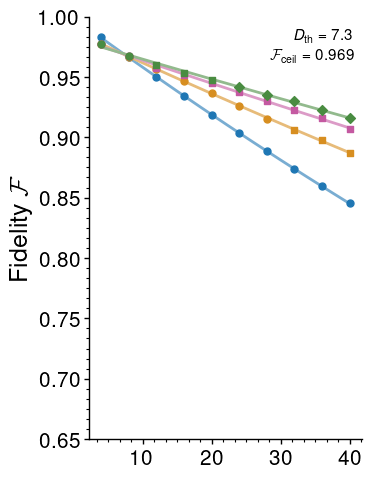

Saved: ../simplified_aer_trotter_data/plots/fid_vs_depth_eps0p001_trialsmax.svg


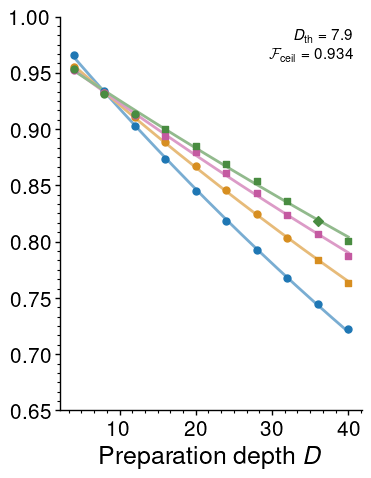

Saved: ../simplified_aer_trotter_data/plots/fid_vs_depth_eps0p002_trialsmax.svg


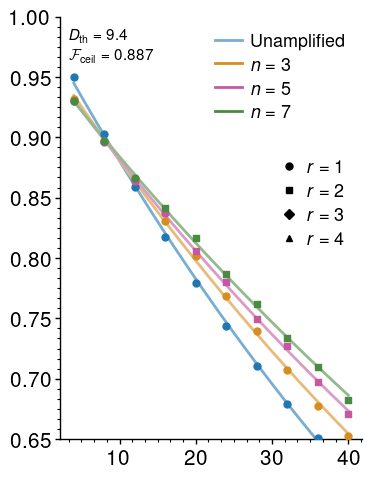

Saved: ../simplified_aer_trotter_data/plots/fid_vs_depth_eps0p003_trialsmax.svg


In [ ]:
# ── Plot 1: Fidelity vs Circuit Depth (fixed ε) — 3 separate plots ───────────
from scipy.optimize import curve_fit
import matplotlib.colors as mcolors

def _exp_model(D, A, gamma):
    return A * np.exp(-gamma * D)

def _lighter(hex_color, factor=0.4):
    base = np.array(mcolors.to_rgb(hex_color))
    return tuple(base + (1 - base) * factor)

def _compute_dth_fceil(plot_data, eps, amp_ns):
    if eps not in plot_data or 1 not in plot_data[eps]:
        return None, None
    t0   = sorted(plot_data[eps][1].keys())[0]
    df_u = plot_data[eps][1][t0]
    xu, yu = (df_u['steps'] * 2).values, df_u['fidelity'].values
    try:
        pu, _ = curve_fit(_exp_model, xu, yu, p0=[yu[0], 0.01],
                          bounds=([0, 0], [2, np.inf]), maxfev=5000)
    except RuntimeError:
        return None, None
    dths, fceils = [], []
    for n in amp_ns:
        if n not in plot_data[eps]:
            continue
        steps_set = sorted({int(s) for tv, df in plot_data[eps][n].items() for s in df['steps']})
        xs, ys = [], []
        for s in steps_set:
            bf, bt = -np.inf, None
            for tv, df in plot_data[eps][n].items():
                row = df[df['steps'] == s]
                if not row.empty:
                    f = float(row['fidelity'].iloc[0])
                    if f > bf:
                        bf, bt = f, tv
            if bt is not None:
                xs.append(s * 2); ys.append(bf)
        if len(xs) < 2:
            continue
        try:
            pa, _ = curve_fit(_exp_model, np.array(xs), np.array(ys),
                              p0=[ys[0], 0.01], bounds=([0, 0], [2, np.inf]), maxfev=5000)
        except RuntimeError:
            continue
        A1, g1 = pu; A2, g2 = pa
        dg = g1 - g2
        if abs(dg) > 1e-12 and A1 > 0 and A2 > 0:
            D0 = np.log(A1 / A2) / dg
            if D0 > 0:
                dths.append(D0)
                fceils.append(_exp_model(D0, *pu))
    if not dths:
        return None, None
    return float(np.mean(dths)), float(np.mean(fceils))


FIGSIZE_SLIM = (500 / PT_PER_INCH * 0.55, 320 / PT_PER_INCH * 1.1)

def plot_fidelity_vs_depth(plot_data, target_eps, trials_req, out_dir,
                           show_ylabel=False, show_xlabel=False,
                           show_legend=False, show_dth_annotation=False,
                           legend_rounds=None, annotation_side='right'):
    if target_eps not in plot_data:
        print(f'No data for eps={target_eps}')
        return

    eps_data = plot_data[target_eps]
    amp_ns   = sorted(n for n in eps_data if n != 1)

    fig, ax = plt.subplots(figsize=FIGSIZE_SLIM)
    style_ax(ax)
    ax.set_ylim(0.65, 1.0)

    # Unamplified
    if 1 in eps_data:
        t_vals = sorted(eps_data[1].keys())
        df = eps_data[1][t_vals[0]]
        deps = (df['steps'] * 2).values
        fids = df['fidelity'].values
        ax.scatter(deps, fids, color=BLUE, marker=round_marker(1), s=markersize**2, zorder=3)
        try:
            pu, _ = curve_fit(_exp_model, deps, fids, p0=[fids[0], 0.01],
                              bounds=([0, 0], [2, np.inf]), maxfev=5000)
            D_fit = np.linspace(deps.min(), deps.max(), 200)
            ax.plot(D_fit, _exp_model(D_fit, *pu), color=_lighter(BLUE), linewidth=2, zorder=2)
        except RuntimeError:
            pass

    # Amplified
    used_rounds = set()
    for n in amp_ns:
        c = n_color(n); cl = _lighter(c)
        steps_set = sorted({int(s) for tv, df in eps_data[n].items() for s in df['steps']})
        xs, ys, best_tvs = [], [], []
        for steps in steps_set:
            bf, bt = -np.inf, None
            for tv, df in eps_data[n].items():
                row = df[df['steps'] == steps]
                if not row.empty:
                    f = float(row['fidelity'].iloc[0])
                    if f > bf:
                        bf, bt = f, tv
            if bt is not None:
                xs.append(steps * 2); ys.append(bf); best_tvs.append(bt)
        xs_arr, ys_arr = np.array(xs), np.array(ys)
        for x, y, tv in zip(xs_arr, ys_arr, best_tvs):
            ax.scatter([x], [y], color=c, marker=round_marker(tv), s=markersize**2, zorder=3)
            used_rounds.add(tv)
        try:
            popt, _ = curve_fit(_exp_model, xs_arr, ys_arr, p0=[ys_arr[0], 0.01],
                                bounds=([0, 0], [2, np.inf]), maxfev=5000)
            D_fit = np.linspace(xs_arr.min(), xs_arr.max(), 200)
            ax.plot(D_fit, _exp_model(D_fit, *popt), color=cl, linewidth=2, zorder=2)
        except RuntimeError:
            pass

    # D_th / F_ceil annotation
    if show_dth_annotation:
        dth, fceil = _compute_dth_fceil(plot_data, target_eps, amp_ns)
        if dth is not None:
            ann = (rf'$D_{{\mathrm{{th}}}}={dth:.1f}$'
                   '\n'
                   rf'$\mathcal{{F}}_{{\mathrm{{ceil}}}}={fceil:.3f}$')
            x_ann = 0.03 if annotation_side == 'left' else 0.97
            ha    = 'left' if annotation_side == 'left' else 'right'
            ax.text(x_ann, 0.97, ann, transform=ax.transAxes,
                    fontsize=legend_fs * 0.85, ha=ha, va='top', linespacing=1.5)

    # Axis labels
    if show_ylabel:
        ax.set_ylabel(r'Fidelity $\mathcal{F}$', fontsize=label_fs)
    if show_xlabel:
        ax.set_xlabel(r'Preparation depth $D$', fontsize=label_fs)

    # Stacked legends
    if show_legend:
        color_handles = [Line2D([0], [0], color=_lighter(BLUE), lw=2, label='Unamplified')]
        color_handles += [Line2D([0], [0], color=n_color(n), lw=2, label=f'$n={n}$')
                          for n in amp_ns]
        round_set = sorted(legend_rounds) if legend_rounds is not None else sorted(used_rounds | {1})
        shape_handles = [
            Line2D([0], [0], color='k', lw=0, marker=round_marker(tv),
                   markersize=markersize, label=f'$r={tv}$')
            for tv in round_set
        ]
        leg1 = ax.legend(handles=color_handles, loc='upper right',
                         bbox_to_anchor=(1.0, 1.0), fontsize=legend_fs,
                         frameon=False, handlelength=1.5, handletextpad=0.5,
                         labelspacing=0.4, borderpad=0.4)
        ax.add_artist(leg1)
        color_leg_height = len(color_handles) * 0.07 + 0.02
        ax.legend(handles=shape_handles, loc='upper right',
                  bbox_to_anchor=(1.0, 1.0 - color_leg_height), fontsize=legend_fs,
                  frameon=False, handlelength=1.0, handletextpad=0.5,
                  labelspacing=0.4, borderpad=0.4)

    eps_tag = str(target_eps).replace('.', 'p')
    fname   = os.path.join(out_dir, f'fid_vs_depth_eps{eps_tag}_trials{trials_req}.svg')
    fig.tight_layout()
    fig.savefig(fname, format='svg')
    plt.show()
    print('Saved:', fname)


plot_fidelity_vs_depth(plot_data, 0.001, TRIALS_REQUEST, OUT_DIR,
                       show_ylabel=True,  show_xlabel=False,
                       show_legend=False, show_dth_annotation=True,
                       annotation_side='right')

plot_fidelity_vs_depth(plot_data, 0.002, TRIALS_REQUEST, OUT_DIR,
                       show_ylabel=False, show_xlabel=True,
                       show_legend=False, show_dth_annotation=True,
                       annotation_side='right')

plot_fidelity_vs_depth(plot_data, 0.003, TRIALS_REQUEST, OUT_DIR,
                       show_ylabel=False, show_xlabel=False,
                       show_legend=True,  show_dth_annotation=True,
                       legend_rounds=sorted(all_rounds),
                       annotation_side='left')

/var/folders/hl/y54530rn3pjgrmkl79jcr2gm0000gn/T/ipykernel_18669/401432423.py:58: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, _ = curve_fit(_exp_model, deps, fids, p0=[fids[0], 0.01],
/var/folders/hl/y54530rn3pjgrmkl79jcr2gm0000gn/T/ipykernel_18669/401432423.py:58: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, _ = curve_fit(_exp_model, deps, fids, p0=[fids[0], 0.01],
/var/folders/hl/y54530rn3pjgrmkl79jcr2gm0000gn/T/ipykernel_18669/401432423.py:58: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, _ = curve_fit(_exp_model, deps, fids, p0=[fids[0], 0.01],


TypeError: unsupported operand type(s) for |: 'list' and 'set'

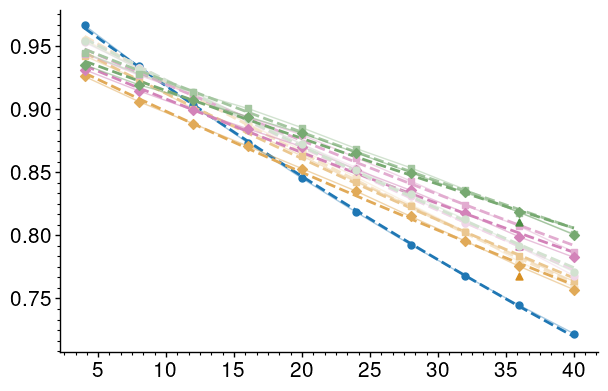

In [ ]:
# ── Plot 0: Fidelity vs Circuit Depth — all rounds, shaded by round ──────────
# Color = n value; shade = round (light→dark for r=1→3); no max over rounds.

import matplotlib.colors as mcolors

def _shade(base_hex, t):
    """Blend base color toward white (t=0) or keep full (t=1)."""
    base = np.array(mcolors.to_rgb(base_hex))
    white = np.ones(3)
    return tuple(white * (1 - t) + base * t)

def plot_fidelity_vs_depth_all_rounds(plot_data, target_eps, trials_req, out_dir):
    if target_eps not in plot_data:
        print(f'No data for eps={target_eps}')
        return

    eps_data = plot_data[target_eps]
    amp_ns   = sorted(n for n in eps_data if n != 1)

    # Collect all rounds present
    all_tv = sorted({tv for n in amp_ns for tv in eps_data[n]})
    n_rounds = max(len(all_tv), 1)
    # Map round index → shade level (lightest for first round, full for last)
    shade_levels = {tv: (i + 1) / n_rounds for i, tv in enumerate(all_tv)}

    fig, ax = plt.subplots(figsize=FIGSIZE)
    style_ax(ax)

    # Unamplified
    if 1 in eps_data:
        t_vals = sorted(eps_data[1].keys())
        df = eps_data[1][t_vals[0]]
        deps = (df['steps'] * 2).values
        fids = df['fidelity'].values
        ax.plot(deps, fids, color=BLUE, linewidth=1, alpha=0.4, zorder=1)
        ax.scatter(deps, fids, color=BLUE, marker=round_marker(1),
                   s=markersize**2, zorder=3)
        try:
            pu, _ = curve_fit(_exp_model, deps, fids, p0=[fids[0], 0.01],
                              bounds=([0, 0], [2, np.inf]), maxfev=5000)
            D_fit = np.linspace(deps.min(), deps.max(), 200)
            ax.plot(D_fit, _exp_model(D_fit, *pu), color=BLUE,
                    linestyle='--', linewidth=2, zorder=2)
        except RuntimeError:
            pass

    # Amplified: one curve per (n, round)
    for n in amp_ns:
        base = n_color(n)
        for tv, df in sorted(eps_data[n].items()):
            c    = _shade(base, shade_levels[tv])
            m    = round_marker(tv)
            deps = (df['steps'] * 2).values
            fids = df['fidelity'].values
            ax.plot(deps, fids, color=c, linewidth=1, alpha=0.5)
            ax.scatter(deps, fids, color=c, marker=m, s=markersize**2, zorder=3)
            try:
                popt, _ = curve_fit(_exp_model, deps, fids, p0=[fids[0], 0.01],
                                    bounds=([0, 0], [2, np.inf]), maxfev=5000)
                D_fit = np.linspace(deps.min(), deps.max(), 200)
                ax.plot(D_fit, _exp_model(D_fit, *popt), color=c,
                        linestyle='--', linewidth=2, zorder=2)
            except RuntimeError:
                pass

    # Legend: color patches for n, marker shapes for rounds
    color_handles = [Line2D([0], [0], color=BLUE, lw=2, linestyle='--',
                            label='Unamplified')]
    color_handles += [
        Line2D([0], [0], color=n_color(n), lw=2, label=f'$n={n}$')
        for n in amp_ns
    ]
    shape_handles = [
        Line2D([0], [0], color='k', lw=0, marker=round_marker(tv),
               markersize=markersize, label=f'$r={tv}$')
        for tv in sorted(all_tv | {1})
    ]

    leg1 = ax.legend(handles=color_handles, loc='upper right', fontsize=legend_fs,
                     frameon=False, handlelength=1.5, handletextpad=0.5,
                     labelspacing=0.4, borderpad=0.4)
    ax.add_artist(leg1)
    ax.legend(handles=shape_handles, loc='center right', fontsize=legend_fs,
              frameon=False, handlelength=1.0, handletextpad=0.5,
              labelspacing=0.4, borderpad=0.4)

    ax.set_xlabel(r'Circuit depth $D = 2M$', fontsize=label_fs)
    ax.set_ylabel(r'Fidelity $\mathcal{F}$',  fontsize=label_fs)

    eps_tag = str(target_eps).replace('.', 'p')
    fname   = os.path.join(out_dir, f'fid_vs_depth_allrounds_eps{eps_tag}_trials{trials_req}.pdf')
    fig.tight_layout()
    fig.savefig(fname)
    plt.show()
    print('Saved:', fname)


plot_fidelity_vs_depth_all_rounds(plot_data, TARGET_EPS, TRIALS_REQUEST, OUT_DIR)

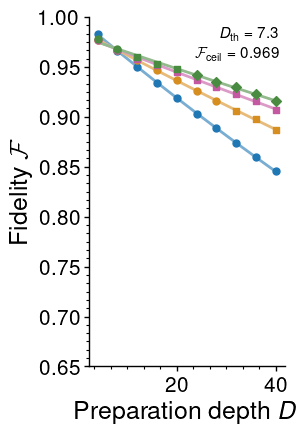

Saved: ../simplified_aer_trotter_data/plots/fid_vs_depth_eps0p001_trialsmax.svg


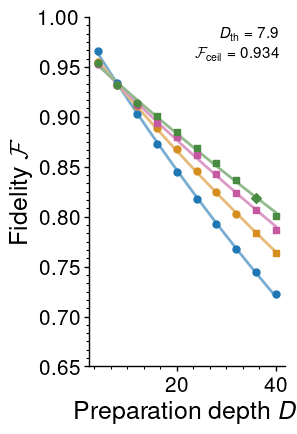

Saved: ../simplified_aer_trotter_data/plots/fid_vs_depth_eps0p002_trialsmax.svg


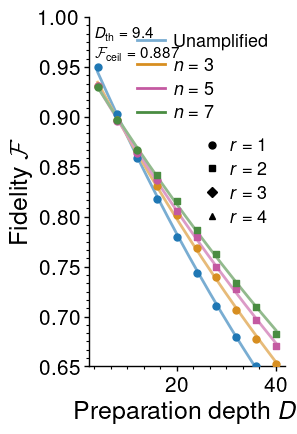

Saved: ../simplified_aer_trotter_data/plots/fid_vs_depth_eps0p003_trialsmax.svg


In [16]:
# ── Plot 1: Fidelity vs Circuit Depth (fixed ε) — 3 separate plots ───────────
from scipy.optimize import curve_fit
import matplotlib.colors as mcolors

def _exp_model(D, A, gamma):
    return A * np.exp(-gamma * D)

def _lighter(hex_color, factor=0.4):
    base = np.array(mcolors.to_rgb(hex_color))
    return tuple(base + (1 - base) * factor)

def _compute_dth_fceil(plot_data, eps, amp_ns):
    if eps not in plot_data or 1 not in plot_data[eps]:
        return None, None
    t0   = sorted(plot_data[eps][1].keys())[0]
    df_u = plot_data[eps][1][t0]
    xu, yu = (df_u['steps'] * 2).values, df_u['fidelity'].values
    try:
        pu, _ = curve_fit(_exp_model, xu, yu, p0=[yu[0], 0.01],
                          bounds=([0, 0], [2, np.inf]), maxfev=5000)
    except RuntimeError:
        return None, None
    dths, fceils = [], []
    for n in amp_ns:
        if n not in plot_data[eps]:
            continue
        steps_set = sorted({int(s) for tv, df in plot_data[eps][n].items() for s in df['steps']})
        xs, ys = [], []
        for s in steps_set:
            bf, bt = -np.inf, None
            for tv, df in plot_data[eps][n].items():
                row = df[df['steps'] == s]
                if not row.empty:
                    f = float(row['fidelity'].iloc[0])
                    if f > bf:
                        bf, bt = f, tv
            if bt is not None:
                xs.append(s * 2); ys.append(bf)
        if len(xs) < 2:
            continue
        try:
            pa, _ = curve_fit(_exp_model, np.array(xs), np.array(ys),
                              p0=[ys[0], 0.01], bounds=([0, 0], [2, np.inf]), maxfev=5000)
        except RuntimeError:
            continue
        A1, g1 = pu; A2, g2 = pa
        dg = g1 - g2
        if abs(dg) > 1e-12 and A1 > 0 and A2 > 0:
            D0 = np.log(A1 / A2) / dg
            if D0 > 0:
                dths.append(D0)
                fceils.append(_exp_model(D0, *pu))
    if not dths:
        return None, None
    return float(np.mean(dths)), float(np.mean(fceils))


FIGSIZE_SLIM = (220 / PT_PER_INCH, 320 / PT_PER_INCH)

def plot_fidelity_vs_depth(plot_data, target_eps, trials_req, out_dir,
                           show_ylabel=False, show_xlabel=False,
                           show_legend=False, show_dth_annotation=False,
                           legend_rounds=None, annotation_side='right'):
    if target_eps not in plot_data:
        print(f'No data for eps={target_eps}')
        return

    eps_data = plot_data[target_eps]
    amp_ns   = sorted(n for n in eps_data if n != 1)

    fig, ax = plt.subplots(figsize=FIGSIZE_SLIM)
    style_ax(ax)
    ax.set_ylim(0.65, 1.0)

    # Unamplified
    if 1 in eps_data:
        t_vals = sorted(eps_data[1].keys())
        df = eps_data[1][t_vals[0]]
        deps = (df['steps'] * 2).values
        fids = df['fidelity'].values
        ax.scatter(deps, fids, color=BLUE, marker=round_marker(1), s=markersize**2, zorder=3)
        try:
            pu, _ = curve_fit(_exp_model, deps, fids, p0=[fids[0], 0.01],
                              bounds=([0, 0], [2, np.inf]), maxfev=5000)
            D_fit = np.linspace(deps.min(), deps.max(), 200)
            ax.plot(D_fit, _exp_model(D_fit, *pu), color=_lighter(BLUE), linewidth=2, zorder=2)
        except RuntimeError:
            pass

    # Amplified
    used_rounds = set()
    for n in amp_ns:
        c = n_color(n); cl = _lighter(c)
        steps_set = sorted({int(s) for tv, df in eps_data[n].items() for s in df['steps']})
        xs, ys, best_tvs = [], [], []
        for steps in steps_set:
            bf, bt = -np.inf, None
            for tv, df in eps_data[n].items():
                row = df[df['steps'] == steps]
                if not row.empty:
                    f = float(row['fidelity'].iloc[0])
                    if f > bf:
                        bf, bt = f, tv
            if bt is not None:
                xs.append(steps * 2); ys.append(bf); best_tvs.append(bt)
        xs_arr, ys_arr = np.array(xs), np.array(ys)
        for x, y, tv in zip(xs_arr, ys_arr, best_tvs):
            ax.scatter([x], [y], color=c, marker=round_marker(tv), s=markersize**2, zorder=3)
            used_rounds.add(tv)
        try:
            popt, _ = curve_fit(_exp_model, xs_arr, ys_arr, p0=[ys_arr[0], 0.01],
                                bounds=([0, 0], [2, np.inf]), maxfev=5000)
            D_fit = np.linspace(xs_arr.min(), xs_arr.max(), 200)
            ax.plot(D_fit, _exp_model(D_fit, *popt), color=cl, linewidth=2, zorder=2)
        except RuntimeError:
            pass

    # D_th / F_ceil annotation
    if show_dth_annotation:
        dth, fceil = _compute_dth_fceil(plot_data, target_eps, amp_ns)
        if dth is not None:
            ann = (rf'$D_{{\mathrm{{th}}}}={dth:.1f}$'
                   '\n'
                   rf'$\mathcal{{F}}_{{\mathrm{{ceil}}}}={fceil:.3f}$')
            x_ann = 0.03 if annotation_side == 'left' else 0.97
            ha    = 'left' if annotation_side == 'left' else 'right'
            ax.text(x_ann, 0.97, ann, transform=ax.transAxes,
                    fontsize=legend_fs * 0.85, ha=ha, va='top', linespacing=1.5)

    # Axis labels
    if show_ylabel:
        ax.set_ylabel(r'Fidelity $\mathcal{F}$', fontsize=label_fs)
    if show_xlabel:
        ax.set_xlabel(r'Preparation depth $D$', fontsize=label_fs)

    # Stacked legends
    if show_legend:
        color_handles = [Line2D([0], [0], color=_lighter(BLUE), lw=2, label='Unamplified')]
        color_handles += [Line2D([0], [0], color=n_color(n), lw=2, label=f'$n={n}$')
                          for n in amp_ns]
        round_set = sorted(legend_rounds) if legend_rounds is not None else sorted(used_rounds | {1})
        shape_handles = [
            Line2D([0], [0], color='k', lw=0, marker=round_marker(tv),
                   markersize=markersize, label=f'$r={tv}$')
            for tv in round_set
        ]
        leg1 = ax.legend(handles=color_handles, loc='upper right',
                         bbox_to_anchor=(1.0, 1.0), fontsize=legend_fs,
                         frameon=False, handlelength=1.5, handletextpad=0.5,
                         labelspacing=0.4, borderpad=0.4)
        ax.add_artist(leg1)
        color_leg_height = len(color_handles) * 0.07 + 0.02
        ax.legend(handles=shape_handles, loc='upper right',
                  bbox_to_anchor=(1.0, 1.0 - color_leg_height), fontsize=legend_fs,
                  frameon=False, handlelength=1.0, handletextpad=0.5,
                  labelspacing=0.4, borderpad=0.4)

    eps_tag = str(target_eps).replace('.', 'p')
    fname   = os.path.join(out_dir, f'fid_vs_depth_eps{eps_tag}_trials{trials_req}.svg')
    fig.tight_layout()
    fig.savefig(fname, format='svg')
    plt.show()
    print('Saved:', fname)


plot_fidelity_vs_depth(plot_data, 0.001, TRIALS_REQUEST, OUT_DIR,
                       show_ylabel=True,  show_xlabel=True,
                       show_legend=False, show_dth_annotation=True,
                       annotation_side='right')

plot_fidelity_vs_depth(plot_data, 0.002, TRIALS_REQUEST, OUT_DIR,
                       show_ylabel=True, show_xlabel=True,
                       show_legend=False, show_dth_annotation=True,
                       annotation_side='right')

plot_fidelity_vs_depth(plot_data, 0.003, TRIALS_REQUEST, OUT_DIR,
                       show_ylabel=True, show_xlabel=True,
                       show_legend=True,  show_dth_annotation=True,
                       legend_rounds=sorted(all_rounds),
                       annotation_side='left')

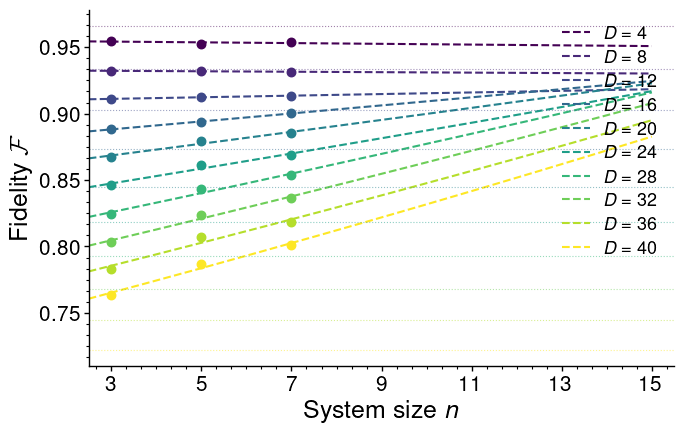

Saved: ../simplified_aer_trotter_data/plots/fid_vs_n_extrap_eps0p002_trialsmax.svg


In [18]:
# ── Plot 1b: Fidelity vs n — extrapolated per depth D (fixed ε) ──────────────
# For each available depth D at TARGET_EPS, fit F(n) = A·exp(b·n) across
# n=3,5,7 (best round) and extrapolate to larger n.

_target_eps = TARGET_EPS if 'TARGET_EPS' in dir() else 0.002

def plot_fidelity_vs_n_extrap(plot_data, target_eps, trials_req, out_dir,
                               n_extrap=15):
    if target_eps not in plot_data:
        print(f'No data for eps={target_eps}')
        return

    eps_data = plot_data[target_eps]
    amp_ns   = sorted(n for n in eps_data if n != 1)

    # Collect all depths shared across amplified n values
    all_depths = sorted({
        int(s) * 2
        for n in amp_ns
        for tv, df in eps_data[n].items()
        for s in df['steps']
    })

    # Color each depth with a sequential palette
    cmap   = plt.cm.viridis
    colors = [cmap(i / max(len(all_depths) - 1, 1)) for i in range(len(all_depths))]

    fig, ax = plt.subplots(figsize=FIGSIZE)
    style_ax(ax)

    n_fit_range = np.linspace(min(amp_ns) - 0.5, n_extrap, 300)

    for depth, color in zip(all_depths, colors):
        steps = depth // 2
        label_str = f'$D={depth}$'

        xs, ys = [], []
        for n in amp_ns:
            bf, bt = -np.inf, None
            for tv, df in eps_data[n].items():
                row = df[df['steps'] == steps]
                if not row.empty:
                    f = float(row['fidelity'].iloc[0])
                    if f > bf:
                        bf, bt = f, tv
            if bt is not None:
                xs.append(n); ys.append(bf)

        if len(xs) < 2:
            continue

        ax.scatter(xs, ys, color=color, s=markersize**2 * 1.5, zorder=3)

        try:
            popt, _ = curve_fit(
                lambda n, A, b: A * np.exp(b * np.array(n, dtype=float)),
                xs, ys, p0=[ys[0], 0.0],
                bounds=([0, -np.inf], [2, np.inf]), maxfev=5000
            )
            y_fit = popt[0] * np.exp(popt[1] * n_fit_range)
            ax.plot(n_fit_range, y_fit, color=color, linewidth=1.5,
                    linestyle='--', label=label_str)
        except RuntimeError:
            ax.plot(xs, ys, color=color, linewidth=1.5, linestyle='--', label=label_str)

    # Unamplified reference lines per depth
    if 1 in eps_data:
        t0   = sorted(eps_data[1].keys())[0]
        df_u = eps_data[1][t0]
        for depth, color in zip(all_depths, colors):
            row = df_u[df_u['steps'] == depth // 2]
            if not row.empty:
                f_u = float(row['fidelity'].iloc[0])
                ax.axhline(f_u, color=color, linewidth=0.8, linestyle=':', alpha=0.5)

    ax.set_xlabel(r'System size $n$', fontsize=label_fs)
    ax.set_ylabel(r'Fidelity $\mathcal{F}$', fontsize=label_fs)
    ax.set_xticks(list(amp_ns) + list(range(max(amp_ns) + 2, n_extrap + 1, 2)))
    ax.set_xlim(min(amp_ns) - 0.5, n_extrap + 0.5)
    ax.legend(fontsize=legend_fs, frameon=False, loc='upper right',
              handlelength=1.5, labelspacing=0.4)

    eps_tag = str(target_eps).replace('.', 'p')
    fname   = os.path.join(out_dir, f'fid_vs_n_extrap_eps{eps_tag}_trials{trials_req}.svg')
    fig.tight_layout()
    fig.savefig(fname, format='svg')
    plt.show()
    print('Saved:', fname)


plot_fidelity_vs_n_extrap(plot_data, _target_eps, TRIALS_REQUEST, OUT_DIR)

In [14]:
# ── Diagnostic: curves + D₀ values at TARGET_EPS ────────────────────────────
_eps = TARGET_EPS
_eps_data = plot_data.get(_eps, {})

print(f'eps = {_eps}\n')

# Unamplified
_pu = None
if 1 in _eps_data:
    _t0 = sorted(_eps_data[1].keys())[0]
    _df = _eps_data[1][_t0]
    _xu = (_df['steps'] * 2).values
    _yu = _df['fidelity'].values
    print('Unamplified curve (D, F):')
    for d, f in zip(_xu, _yu):
        print(f'  D={d:4d}  F={f:.4f}')
    try:
        _pu, _ = curve_fit(_exp_model, _xu, _yu, p0=[_yu[0], 0.01],
                           bounds=([0,0],[2,np.inf]), maxfev=5000)
        print(f'  Exp fit: A={_pu[0]:.4f}, γ={_pu[1]:.5f}')
    except RuntimeError:
        print('  Exp fit failed')
    print()

# Amplified — per n
_unamp_dict = dict(zip(_xu, _yu)) if _pu is not None else {}

for _n in sorted(n for n in _eps_data if n != 1):
    _steps_set = sorted({int(s) for _tv, _df in _eps_data[_n].items() for s in _df['steps']})
    _xs, _ys, _tvs = [], [], []
    for _s in _steps_set:
        _bf, _bt = -np.inf, None
        for _tv, _df in _eps_data[_n].items():
            _row = _df[_df['steps'] == _s]
            if not _row.empty:
                _f = float(_row['fidelity'].iloc[0])
                if _f > _bf:
                    _bf, _bt = _f, _tv
        if _bt is not None:
            _xs.append(_s * 2); _ys.append(_bf); _tvs.append(_bt)

    print(f'n={_n} max-over-rounds curve (D, F, best_r):')
    for d, f, t in zip(_xs, _ys, _tvs):
        _uf = _unamp_dict.get(d, float('nan'))
        print(f'  D={d:4d}  F_amp={f:.4f}  F_unamp={_uf:.4f}  diff={f-_uf:+.4f}  r={t}')

    # Raw crossing: first D where amp > unamp
    _crossed = [(d, fa, _unamp_dict[d]) for d, fa in zip(_xs, _ys)
                if d in _unamp_dict and fa > _unamp_dict[d]]
    if _crossed:
        print(f'  Raw crossing (first D where F_amp > F_unamp): D={_crossed[0][0]}')
    else:
        print('  Raw crossing: amplified never exceeds unamplified in data range')

    _xa, _ya = np.array(_xs), np.array(_ys)
    try:
        _pa, _ = curve_fit(_exp_model, _xa, _ya, p0=[_ya[0], 0.01],
                           bounds=([0,0],[2,np.inf]), maxfev=5000)
        print(f'  Exp fit: A={_pa[0]:.4f}, γ={_pa[1]:.5f}')
        if _pu is not None:
            A1,g1 = _pu; A2,g2 = _pa
            dg = g1 - g2
            if abs(dg) > 1e-12 and A1 > 0 and A2 > 0:
                _d0 = np.log(A1/A2) / dg
                print(f'  D₀ from exp-fit intersection = {_d0:.2f}')
            else:
                print('  D₀ undefined (parallel fits)')
    except RuntimeError:
        print('  Exp fit failed')
    print()

NameError: name 'TARGET_EPS' is not defined

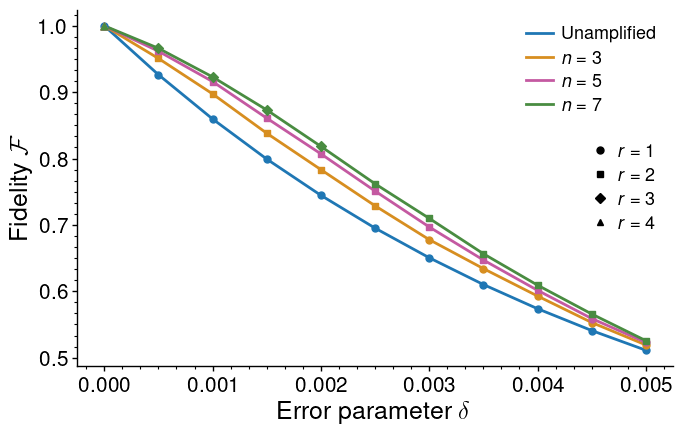

Saved: ../simplified_aer_trotter_data/plots/fid_vs_eps_depth36_trialsmax.svg


In [7]:
# ── Plot 2: Fidelity vs Noise Strength (fixed depth) ─────────────────────────
# Color = n value; at each epsilon, maximize over rounds → marker shows best round

def plot_fidelity_vs_epsilon(plot_data, target_depth, trials_req, out_dir,
                             all_rounds=None, label='', figsize=None,
                             show_legend=True, show_xlabel=True, show_ylabel=True,
                             font_scale=1.0):
    target_steps = target_depth // 2

    _label_fs  = int(label_fs  * font_scale)
    _legend_fs = int(legend_fs * font_scale)
    _tick_fs   = int(tick_fs   * font_scale)

    # n_best[n] = list of (eps, best_fid, best_tv)
    n_best = defaultdict(list)

    for eps in sorted(plot_data.keys()):
        for n, t_map in plot_data[eps].items():
            best_fid, best_tv = -np.inf, None
            for t_val, df in t_map.items():
                row = df[df['steps'] == target_steps]
                if not row.empty:
                    fid = float(row['fidelity'].iloc[0])
                    if fid > best_fid:
                        best_fid, best_tv = fid, t_val
            if best_tv is not None:
                n_best[n].append((eps, best_fid, best_tv))

    amp_ns = sorted(n for n in n_best if n != 1)
    used_rounds = set()

    fig, ax = plt.subplots(figsize=figsize or FIGSIZE)
    style_ax(ax)
    ax.tick_params(which='major', labelsize=_tick_fs)
    ax.tick_params(which='minor', labelsize=_tick_fs)

    # Unamplified — solid line + r=1 markers (same style as amplified)
    if 1 in n_best:
        pts = np.array([(e, f) for e, f, _ in n_best[1]])
        ax.plot(pts[:, 0], pts[:, 1], color=BLUE, linewidth=2, zorder=1)
        ax.scatter(pts[:, 0], pts[:, 1], color=BLUE, marker=round_marker(1),
                   s=markersize**2, zorder=3)

    # Amplified
    for n in amp_ns:
        c = n_color(n)
        pts = n_best[n]
        xs = [p[0] for p in pts]
        ys = [p[1] for p in pts]
        tvs = [p[2] for p in pts]
        ax.plot(xs, ys, color=c, linewidth=2)
        for x, y, tv in zip(xs, ys, tvs):
            ax.scatter([x], [y], color=c, marker=round_marker(tv), s=markersize**2, zorder=3)
            used_rounds.add(tv)

    if show_legend:
        legend_round_set = sorted(set(all_rounds) | used_rounds | {1}) if all_rounds else sorted(used_rounds | {1})
        color_handles = [Line2D([0], [0], color=BLUE, lw=2, label='Unamplified')]
        color_handles += [
            Line2D([0], [0], color=n_color(n), lw=2, label=f'$n={n}$')
            for n in amp_ns
        ]
        shape_handles = [
            Line2D([0], [0], color='k', lw=0, marker=round_marker(tv), markersize=markersize,
                   label=f'$r={tv}$')
            for tv in legend_round_set
        ]
        leg1 = ax.legend(handles=color_handles, loc='upper right', fontsize=_legend_fs,
                         frameon=False, handlelength=1.5, handletextpad=0.5,
                         labelspacing=0.4, borderpad=0.4)
        ax.add_artist(leg1)
        ax.legend(handles=shape_handles, loc='center right', fontsize=_legend_fs,
                  frameon=False, handlelength=1.0, handletextpad=0.5,
                  labelspacing=0.4, borderpad=0.4)

    if show_xlabel:
        ax.set_xlabel(r'Error parameter $\delta$', fontsize=_label_fs)
    if show_ylabel:
        ax.set_ylabel(r'Fidelity $\mathcal{F}$', fontsize=_label_fs)

    tag = f'_{label}' if label else ''
    fname = os.path.join(out_dir, f'fid_vs_eps_depth{target_depth}{tag}_trials{trials_req}.svg')
    fig.tight_layout()
    fig.savefig(fname, format='svg')
    plt.show()
    print('Saved:', fname)


plot_fidelity_vs_epsilon(plot_data, TARGET_DEPTH, TRIALS_REQUEST, OUT_DIR,
                         all_rounds=all_rounds)

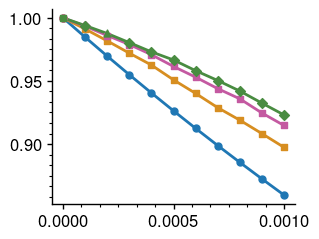

Saved: ../simplified_aer_trotter_data/plots/fid_vs_eps_depth36_zoomed_trialsmax.svg


In [209]:
# ── Plot 2b: Fidelity vs delta — zoomed epsilon range (inset size) ───────────
# Uses zoomed_results data (ε = 0 to 0.001 in steps of 0.0001).

TARGET_DEPTH_Z  = all_steps_z[0] * 2
FIGSIZE_INSET   = (240 / PT_PER_INCH, 180 / PT_PER_INCH)

plot_fidelity_vs_epsilon(plot_data_z, TARGET_DEPTH_Z, TRIALS_REQUEST, OUT_DIR,
                         label='zoomed', figsize=FIGSIZE_INSET,
                         show_legend=False, show_xlabel=False, show_ylabel=False,
                         font_scale=0.8)

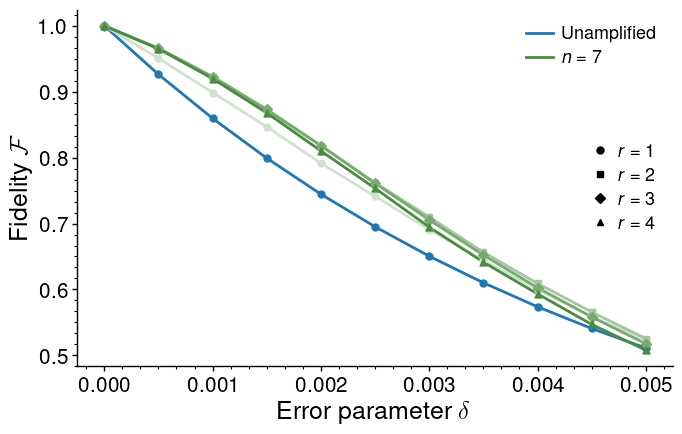

Saved: ../simplified_aer_trotter_data/plots/fid_vs_eps_n7_allrounds_depth36_trialsmax.svg


In [10]:
# ── Plot: Fidelity vs delta — n=7 only, all rounds r=1..4 ────────────────────
# Each round shown as a separate shaded curve at fixed TARGET_DEPTH.

def plot_fid_vs_eps_n7_allrounds(plot_data, target_depth, trials_req, out_dir, show_n=7):
    target_steps = target_depth // 2

    # Collect (eps, fid) per round for show_n
    round_data = defaultdict(list)   # t_val → [(eps, fid), ...]
    unamp_pts  = []

    for eps in sorted(plot_data.keys()):
        eps_data = plot_data[eps]

        # Unamplified
        if 1 in eps_data:
            t0  = sorted(eps_data[1].keys())[0]
            df  = eps_data[1][t0]
            row = df[df['steps'] == target_steps]
            if not row.empty:
                unamp_pts.append((eps, float(row['fidelity'].iloc[0])))

        # n=show_n, per round
        if show_n not in eps_data:
            continue
        for t_val, df in eps_data[show_n].items():
            row = df[df['steps'] == target_steps]
            if not row.empty:
                round_data[t_val].append((eps, float(row['fidelity'].iloc[0])))

    all_tv   = sorted(round_data.keys())
    n_rounds = max(len(all_tv), 1)
    shade_levels = {tv: (i + 1) / n_rounds for i, tv in enumerate(all_tv)}
    base = n_color(show_n)

    fig, ax = plt.subplots(figsize=FIGSIZE)
    style_ax(ax)

    # Unamplified
    if unamp_pts:
        xs, ys = zip(*unamp_pts)
        ax.plot(xs, ys, color=BLUE, linewidth=2, zorder=1)
        ax.scatter(xs, ys, color=BLUE, marker=round_marker(1), s=markersize**2, zorder=3)

    # n=show_n per round
    for tv in all_tv:
        pts = sorted(round_data[tv])
        xs, ys = zip(*pts)
        c = _shade(base, shade_levels[tv])
        m = round_marker(tv)
        ax.plot(xs, ys, color=c, linewidth=2, zorder=1)
        ax.scatter(xs, ys, color=c, marker=m, s=markersize**2, zorder=3)

    color_handles = [
        Line2D([0], [0], color=BLUE, lw=2, label='Unamplified'),
        Line2D([0], [0], color=n_color(show_n), lw=2, label=f'$n={show_n}$'),
    ]
    shape_handles = [
        Line2D([0], [0], color='k', lw=0, marker=round_marker(tv),
               markersize=markersize, label=f'$r={tv}$')
        for tv in sorted(set(all_tv) | {1})
    ]

    leg1 = ax.legend(handles=color_handles, loc='upper right', fontsize=legend_fs,
                     frameon=False, handlelength=1.5, handletextpad=0.5,
                     labelspacing=0.4, borderpad=0.4)
    ax.add_artist(leg1)
    ax.legend(handles=shape_handles, loc='center right', fontsize=legend_fs,
              frameon=False, handlelength=1.0, handletextpad=0.5,
              labelspacing=0.4, borderpad=0.4)

    ax.set_xlabel(r'Error parameter $\delta$', fontsize=label_fs)
    ax.set_ylabel(r'Fidelity $\mathcal{F}$',   fontsize=label_fs)

    fname = os.path.join(out_dir, f'fid_vs_eps_n{show_n}_allrounds_depth{target_depth}_trials{trials_req}.svg')
    fig.tight_layout()
    fig.savefig(fname, format='svg')
    plt.show()
    print('Saved:', fname)


plot_fid_vs_eps_n7_allrounds(plot_data, TARGET_DEPTH, TRIALS_REQUEST, OUT_DIR, show_n=7)

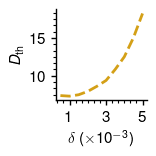

Saved: ../simplified_aer_trotter_data/plots/D0_vs_eps_trialsmax.svg


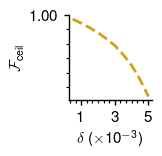

Saved: ../simplified_aer_trotter_data/plots/Fceil_vs_eps_trialsmax.svg


In [205]:
# ── Plot 3: D_th and F_ceil vs delta ─────────────────────────────────────────
# D_th = average D₀ over n=3,5,7 at each eps.
# F_ceil = unamplified exp fit evaluated at D_th.

from scipy.optimize import curve_fit
from collections import Counter
from matplotlib.ticker import FixedLocator, FuncFormatter

def _fit_exp_curve(xs, ys):
    try:
        p0 = [max(ys[0], 1e-6), 0.01]
        popt, _ = curve_fit(
            lambda x, A, g: A * np.exp(-g * x),
            xs, ys, p0=p0,
            bounds=([0, 0], [2, np.inf]), maxfev=5000
        )
        return popt
    except RuntimeError:
        return None


def _d0_from_exp_fits(p_unamp, p_amp):
    A1, g1 = p_unamp
    A2, g2 = p_amp
    dg = g1 - g2
    if abs(dg) < 1e-12 or A1 <= 0 or A2 <= 0:
        return None
    D0 = np.log(A1 / A2) / dg
    return float(D0) if D0 > 0 else None


def _unamplified_curve(raw_data, eps):
    if eps not in raw_data or 1 not in raw_data[eps]:
        return None, None
    sm = raw_data[eps][1]
    xs, ys = [], []
    for s in sorted(sm):
        for stats in sm[s].values():
            if stats['shots'] > 0:
                xs.append(s * 2)
                ys.append(stats['w_sum'] / stats['shots'])
    if len(xs) < 2:
        return None, None
    return np.array(xs), np.array(ys)


def _compute_dth_fceil_vs_eps(raw_data, all_ns):
    """Returns lists (eps_list, dth_list, fceil_list)."""
    sorted_eps = sorted(raw_data.keys())
    eps_out, dth_out, fceil_out = [], [], []

    for eps in sorted_eps:
        x1, y1 = _unamplified_curve(raw_data, eps)
        if x1 is None:
            continue
        p_unamp = _fit_exp_curve(x1, y1)
        if p_unamp is None:
            continue

        d0s = []
        for n in all_ns:
            if n not in raw_data[eps]:
                continue
            smn       = raw_data[eps][n]
            all_tv    = {tv for s in smn for tv in smn[s]}
            steps_set = sorted(smn.keys())

            xs, ys = [], []
            for s in steps_set:
                best_fid, best_tv = -np.inf, None
                for tv in all_tv:
                    if tv in smn[s] and smn[s][tv]['shots'] > 0:
                        fid = smn[s][tv]['w_sum'] / smn[s][tv]['shots']
                        if fid > best_fid:
                            best_fid, best_tv = fid, tv
                if best_tv is not None:
                    xs.append(s * 2); ys.append(best_fid)

            if len(xs) < 2:
                continue
            p_amp = _fit_exp_curve(np.array(xs), np.array(ys))
            if p_amp is None:
                continue
            d0 = _d0_from_exp_fits(p_unamp, p_amp)
            if d0 is not None:
                d0s.append(d0)

        if not d0s:
            continue
        dth = float(np.mean(d0s))
        A_u, g_u = p_unamp
        fceil = A_u * np.exp(-g_u * dth)
        eps_out.append(eps); dth_out.append(dth); fceil_out.append(fceil)

    return eps_out, dth_out, fceil_out


def _make_eps_ax(ax, fs):
    ax.xaxis.set_major_locator(FixedLocator([0.001, 0.003, 0.005]))
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(round(x * 1000))}'))
    ax.set_xlabel(r'$\delta$ ($\times 10^{-3}$)', fontsize=fs)
    ax.tick_params(labelsize=fs)


FIGSIZE_D0 = (120 / PT_PER_INCH, 120 / PT_PER_INCH)
FIGSIZE_D1 = (124 / PT_PER_INCH, 120 / PT_PER_INCH)
COLOR_DTH  = '#d4a017'
_fs        = int(label_fs * 0.64)

eps_list, dth_list, fceil_list = _compute_dth_fceil_vs_eps(raw_data, all_ns)

# ── Plot 3a: D_th vs delta ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=FIGSIZE_D0)
style_ax(ax)
ax.plot(eps_list, dth_list, color=COLOR_DTH, linewidth=2, linestyle='--', zorder=4)
_make_eps_ax(ax, _fs)
ax.set_ylabel(r'$D_{\mathrm{th}}$', fontsize=_fs)
fig.tight_layout()
fname_dth = os.path.join(OUT_DIR, f'D0_vs_eps_trials{TRIALS_REQUEST}.svg')
fig.savefig(fname_dth, format='svg')
plt.show()
print('Saved:', fname_dth)

# ── Plot 3b: F_ceil vs delta ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=FIGSIZE_D1)
style_ax(ax)
ax.plot(eps_list, fceil_list, color=COLOR_DTH, linewidth=2, linestyle='--', zorder=4)
_make_eps_ax(ax, _fs)
ax.set_ylabel(r'$\mathcal{F}_{\mathrm{ceil}}$', fontsize=_fs)
ymin = min(fceil_list) * 0.98
ax.set_ylim(ymin, 1.0)
ax.yaxis.set_major_locator(FixedLocator([round(ymin, 2), 1.0]))
fig.tight_layout()
fname_fc = os.path.join(OUT_DIR, f'Fceil_vs_eps_trials{TRIALS_REQUEST}.svg')
fig.savefig(fname_fc, format='svg')
plt.show()
print('Saved:', fname_fc)